# Time Series Mean Reversion

In [7]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
from pandas import DataFrame, read_csv

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.plots import curve, comparison, stack
from lib.data import arima, adf, stats

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Stationary Autoregressive Process 

Stationary autoregressive time series are mean reverting. Here the USD.CAD exchange rate is tested for staionarity using the ADF test.

In [8]:
file_path = os.path.abspath('../../algorithmic_trading/data/USD_CAD.csv')
usd_cad = read_csv(file_path, index_col=0, parse_dates=True)
usd_cad.head()

,Close/Last,Volume,Open,High,Low
Date,,,,,
2023-12-08,1.3584,NaN,1.3594,1.3611,1.3551
2023-12-07,1.3577,NaN,1.3594,1.3603,1.3571
2023-12-06,1.3604,NaN,1.3591,1.3608,1.3589
2023-12-05,1.3570,NaN,1.3570,1.3572,1.3531
2023-12-04,1.3558,NaN,1.3537,1.3566,1.3531


In [9]:
date = usd_cad.index.to_numpy()
exch = usd_cad['Close/Last'].to_numpy()
exch_mean = numpy.full(len(date), numpy.mean(exch))

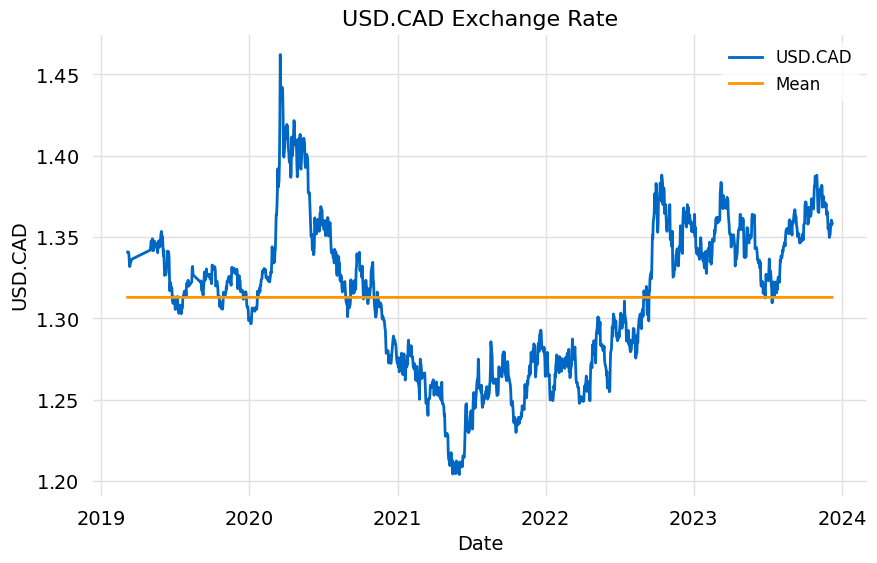

In [14]:
title = 'USD.CAD Exchange Rate'
comparison([exch, exch_mean], date, title=title, xlabel="Date", ylabel="USD.CAD", labels=['USD.CAD', 'Mean'])

In [25]:
result, _ = adf.compute_adf_offset_test(exch, max_lag=12)
result.summary()

╒════════════════╤═════════════╕
│ Test Statistic │   -2.16345  │
├────────────────┼─────────────┤
│ pvalue         │    0.219778 │
├────────────────┼─────────────┤
│ Lags           │    5        │
├────────────────┼─────────────┤
│ Number Obs     │ 1409        │
╘════════════════╧═════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -3.435   │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -2.86359 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -2.56786 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


## Fractional Brownian Motion Process